# 🌟 BioSignal Simulator (BSS) Interactive Demo

Welcome to the interactive tour of **BioSignal Simulator (BSS)**! BSS is a classical digital signal processing (DSP) toolkit in Python for generating clean physiological signals (ECG, EEG, EMG, PPG, EDA, respiration) contaminated by highly realistic, parameterized physical noise models.

In this notebook, we will:
1. Install `biosignal-simulator` from PyPI.
2. Generate clean physiological signals (ECG & PPG).
3. Introduce realistic motion artifacts and colored noise.
4. Mix the clean signals with noise at a targeted Signal-to-Noise Ratio (SNR).
5. Compute diagnostic signal quality metrics.
6. Export simulated signals.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/therajpoots/Biosim/blob/main/demo.ipynb)

In [2]:
# Install the library from PyPI
!pip install biosignal-simulator matplotlib numpy scipy


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\User\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [3]:
import biosignal_simulator as bss
import matplotlib.pyplot as plt
import numpy as np

print(f"BioSignal Simulator version: {bss.__version__ if hasattr(bss, '__version__') else '0.1.3'}")

BioSignal Simulator version: 0.1.3


In [4]:
# 1. ECG Generation using McSharry ODE model
ecg_config = bss.ECGConfig(fs=250.0, duration_s=10.0, heart_rate=72.0)
ecg_generator = bss.ECGGenerator(ecg_config)
ecg_record = bss.SignalMixer(signal_generator=ecg_generator, noise_models=[]).mix()

# 2. PPG Generation with realistic dicrotic notch
ppg_config = bss.PPGConfig(fs=125.0, duration_s=10.0, heart_rate=72.0)
ppg_generator = bss.PPGGenerator(ppg_config)
ppg_record = bss.SignalMixer(signal_generator=ppg_generator, noise_models=[]).mix()

print(f"Generated clean ECG: {ecg_record.clean.shape[0]} samples at {ecg_record.fs} Hz")
print(f"Generated clean PPG: {ppg_record.clean.shape[0]} samples at {ppg_record.fs} Hz")

Generated clean ECG: 2500 samples at 250.0 Hz
Generated clean PPG: 1250 samples at 125.0 Hz


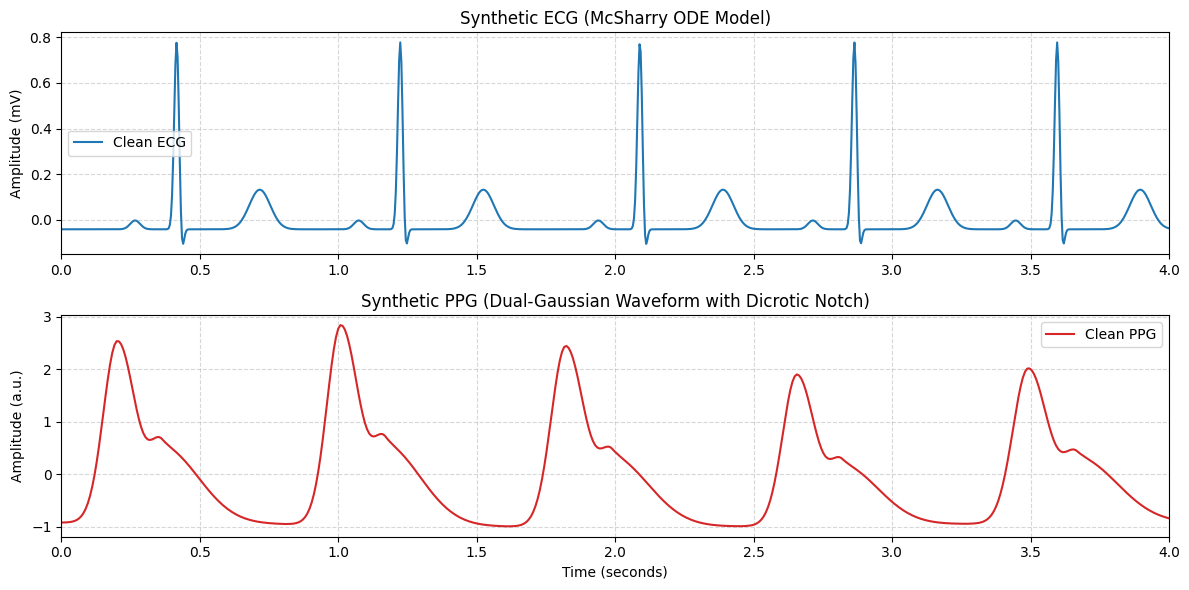

In [5]:
# Plot clean ECG and PPG signals side-by-side
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=False)

# ECG
t_ecg = np.arange(len(ecg_record.clean)) / ecg_record.fs
ax1.plot(t_ecg, ecg_record.clean, color='#1f77b4', lw=1.5, label='Clean ECG')
ax1.set_title('Synthetic ECG (McSharry ODE Model)')
ax1.set_ylabel('Amplitude (mV)')
ax1.set_xlim(0, 4.0)  # Show first 4 seconds
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend()

# PPG
t_ppg = np.arange(len(ppg_record.clean)) / ppg_record.fs
ax2.plot(t_ppg, ppg_record.clean, color='#d62728', lw=1.5, label='Clean PPG')
ax2.set_title('Synthetic PPG (Dual-Gaussian Waveform with Dicrotic Notch)')
ax2.set_ylabel('Amplitude (a.u.)')
ax2.set_xlabel('Time (seconds)')
ax2.set_xlim(0, 4.0)  # Show first 4 seconds
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend()

plt.tight_layout()
plt.show()

In [6]:
# Schedule a ramping Pink Noise artifact (flicker noise: 1/f)
pink_noise = bss.ColoredNoise(exponent=1.0)
pink_scheduler = bss.NoiseScheduler(
    noise_model=pink_noise,
    schedule=bss.RampSchedule(control_times=[0.0, 10.0], levels=[0.0, 0.4])
)

# Generate motion artifact simulating sudden sensor translation
motion_artifact = bss.MotionArtifact(
    lf_amplitude=0.3,
    enable_lf=True,
    enable_impacts=True,
    impact_amplitude=0.8,
    seed=42
)
motion_scheduler = bss.NoiseScheduler(
    noise_model=motion_artifact,
    schedule=bss.StepSchedule(breakpoints=[0.0, 4.0], levels=[0.0, 1.0])
)

print("Scheduled: Pink noise (ramping up) and PPG Motion Artifact (triggered at 4.0s)")

Scheduled: Pink noise (ramping up) and PPG Motion Artifact (triggered at 4.0s)


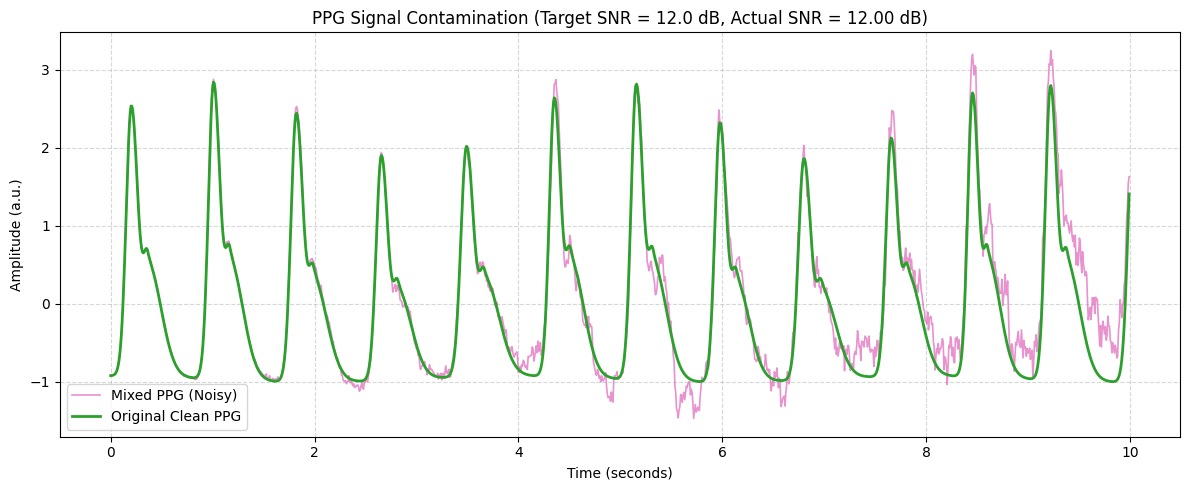

In [7]:
# Mix the clean PPG with the scheduled noises at a target SNR of 12 dB
mixer = bss.SignalMixer(
    signal_generator=ppg_generator,
    noise_models=[pink_scheduler, motion_scheduler],
    target_snr_db=12.0
)
mixed_record = mixer.mix()

# Plot the comparison
fig, ax = plt.subplots(figsize=(12, 5))
t = np.arange(len(mixed_record.clean)) / mixed_record.fs
ax.plot(t, mixed_record.noisy, color='#e377c2', alpha=0.8, label='Mixed PPG (Noisy)', lw=1.2)
ax.plot(t, mixed_record.clean, color='#2ca02c', label='Original Clean PPG', lw=2.0)
ax.set_title(f'PPG Signal Contamination (Target SNR = {mixed_record.target_snr_db} dB, Actual SNR = {mixed_record.snr_db:.2f} dB)')
ax.set_ylabel('Amplitude (a.u.)')
ax.set_xlabel('Time (seconds)')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
from biosignal_simulator.metrics import compute_snr_wideband, compute_prd, compute_correlation

# Compute diagnostic metrics between clean and mixed signals
snr = compute_snr_wideband(mixed_record.clean, mixed_record.noisy, mixed_record.fs)
prd = compute_prd(mixed_record.clean, mixed_record.noisy)
pearson = compute_correlation(mixed_record.clean, mixed_record.noisy)

print("--- Signal Quality Metrics ---")
print(f"SNR (Signal-to-Noise Ratio):      {snr:.2f} dB")
print(f"PRD (Percent Residual Difference): {prd:.2f}%")
print(f"Pearson Correlation:               {pearson:.4f}")

--- Signal Quality Metrics ---
SNR (Signal-to-Noise Ratio):      12.00 dB
PRD (Percent Residual Difference): 25.12%
Pearson Correlation:               0.9737


In [9]:
import os

# Export to HDF5
h5_path = "demo_signal.h5"
bss.BiosignalExporter.export_hdf5(mixed_record, h5_path)

# Verify by importing it back using BiosignalImporter
imported_record = bss.BiosignalImporter.import_hdf5(h5_path)
print(f"Exported HDF5 to: {os.path.abspath(h5_path)}")
print(f"Successfully imported back: {len(imported_record.noisy)} samples at {imported_record.fs} Hz")

# Clean up
if os.path.exists(h5_path):
    os.remove(h5_path)

Exported HDF5 to: e:\Biosim\demo_signal.h5
Successfully imported back: 1250 samples at 125.0 Hz
